In [81]:
using JLD2
using DataFrames
using CSV
using Plots
using CairoMakie
using Statistics
using HiddenMarkovModels
using DriftDiffusionModels
using BSON: @load
using Dates
using Printf

In [41]:
# glmhmm posteriors 
post_file = load("/Users/senne/Downloads/best_gammas2.jld2")
gammas_dict = sort(post_file["gammas_dict"])

# read in params for each model fit
glmhmm_params = CSV.read("/Users/senne/Downloads/FINAL_fit3.csv", DataFrame)

# get needed variables for confusion matrix analysis
unique_animals = sort(unique([split_string[1] for split_string in [split(rat_str, "_") for rat_str in glmhmm_params.rat]]))
best_run = [parse(Int, split(String(k), "_")[2][4:end]) for k in keys(gammas_dict)];



In [42]:
best_run

18-element Vector{Int64}:
  4
 10
  4
  8
  4
  8
  5
  4
 10
  8
  2
  6
  8
  5
  6
  4
  1
  2

In [40]:
gammas_dict

OrderedCollections.OrderedDict{String, Matrix{Float64}} with 18 entries:
  "1029_run4"   => [0.0118465 0.0112703 … 0.254817 0.248366; 0.907179 0.908888 …
  "1052_run10"  => [0.0205715 0.0186696 … 0.747991 0.743474; 0.217595 0.366793 …
  "1054_run4"   => [0.0153371 0.0147474 … 0.947841 0.924089; 0.630283 0.625163 …
  "1059_run8"   => [0.577962 0.0840425 … 0.548685 0.544763; 0.0253707 0.0256194…
  "1060_run4"   => [0.490355 0.355638 … 5.24192e-5 8.3996e-5; 0.00911072 0.0045…
  "1062_run8"   => [0.00125425 0.0004622 … 0.0311586 0.031361; 0.951275 0.96436…
  "1064_run5"   => [0.00328364 0.0271996 … 0.442735 0.235405; 0.875236 0.897772…
  "1065_run4"   => [0.695618 0.863032 … 0.748469 0.162276; 0.304382 0.13673 … 0…
  "1072_run10"  => [0.0133299 0.0156862 … 3.55094e-74 5.12077e-74; 7.42676e-75 …
  "Denna_run8"  => [0.0233082 0.0199725 … 0.0557821 0.0559535; 0.000135502 0.00…
  "Dopey_run2"  => [0.897933 0.902823 … 0.000774384 0.000812332; 0.00132182 0.0…
  "Draco_run6"  => [0.0416461 0.0377

In [53]:
"""
    parse_betas_string(s) -> Vector{Matrix{Float64}}

Parse a CSV field that looks like:
`Any[[-0.1; 0.2; 0.3;;], [1.0; 2.0;;]]`
into `Vector{Matrix{Float64}}` (each inner is n×1).
"""
function parse_betas_string(s::AbstractString)::Vector{Matrix{Float64}}
    mats = Matrix{Float64}[]

    # Grab each matrix payload between '[' and ';;]'
    for m in eachmatch(r"\[\s*(.*?)\s*;;\s*\]"s, s)
        payload = m.captures[1]

        # Extract all numeric literals (incl. exponent notation)
        toks = eachmatch(r"[-+]?(?:\d+\.\d*|\d*\.?\d+)(?:[eE][-+]?\d+)?", payload)
        nums = [parse(Float64, t.match) for t in toks]

        push!(mats, reshape(nums, :, 1))
    end

    return mats
end

function sort_glmmhmm_posterior(name::String, run::Int)
    # posterior for glmhmm
    gammas = gammas_dict["$(name)_run$(run)"]

    # get glm params for the best run
    glm_params = glmhmm_params[(glmhmm_params.rat .== "$(name)_run$(run)"), :]

    betas_str = glm_params.B[1]
    betas = parse_betas_string(betas_str) 

    # sort on beta 2 (i.e., stiumulus gain)
    perm = sortperm(betas; by = B -> B[2], rev=true)
    gammas_sorted = gammas[perm, :]
    return gammas_sorted
end

sort_glmmhmm_posterior (generic function with 1 method)

In [54]:
# set data dirtectory
data_dir = joinpath(@__DIR__, "..", "data")

# read out all BSOn files that have a 4 in them (K=4)
bson_files = filter(f -> occursin("K4", f), readdir(data_dir; join=true))

# read all data into a bson file. We need to define the following struct for it to work right.
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

ddmhmm_fits = DDMHMMFit[]  

for bson_file in bson_files
    @load bson_file fit   # defines `fit` in this scope
    push!(ddmhmm_fits, fit)
end

# set data path (assumes you are in the project root)
data_file = joinpath("..", "data", "processed_rat_data.csv.gz")

# Read in and structure data
rat_df = CSV.read(data_file, DataFrame)
rat_df = rat_df[rat_df.daily .== "24 hr", :] # only keep 24 hour data

# preprocess the data to have numerics
replace!(rat_df[!, :choose_right], 0 => -1)

mapping = Dict("right" => 1, "left" => -1)
DataFrames.transform!(rat_df, :correct_side => ByRow(cs -> get(mapping, cs, missing)) => :correct_side_numeric)

names = sort(unique(rat_df[!, "name"]))

#=
creates data to pass to the ddm-hmm
=#
function data_for_ddmhmm(rat_idx::Int)
    rat = names[rat_idx]

    rat_of_interest = rat_df[rat_df.name .== rat, :]
    dates = [Date(split(dt)[1]) for dt in rat_of_interest.trial_datetime]
        
    # Get unique dates in chronological order
    unique_dates = sort(unique(dates))
        
    # Create a vector of vectors, where each inner vector contains DDMResults for one day
    results_by_date = Vector{Vector{DDMResult}}()

    for date in unique_dates
        # Get indices for this date
        day_indices = findall(dates .== date)

        # Skip days with no valid data
        if isempty(day_indices)
            continue
        end

        # Extract RTs and outcomes for this date
        day_rts = rat_of_interest.rt[day_indices]
        day_outcomes = rat_of_interest.choose_right[day_indices]
        day_stim_side = rat_of_interest.correct_side_numeric[day_indices]
            
        # Create DDMResult objects for this day
        day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]
        
        # Add to our vector of vectors
        push!(results_by_date, day_results)
    end

    # Now calculate the sequence ends (cumulative sum of lengths)
	seq_ends = cumsum([length(seq) for seq in results_by_date])
	
	# Concatenate all results into a single vector
	all_results = reduce(vcat, results_by_date)

    return all_results, seq_ends, results_by_date
end

function sort_ddmhmm_posterior(rat_idx::Int)
    hmm = ddmhmm_fits[rat_idx].hmm

    # posterior
    gammas, ll = forward_backward(ddmhmm_fits[rat_idx].hmm, data_for_ddmhmm(rat_idx)[1]; seq_ends=data_for_ddmhmm(rat_idx)[2])

    # get accuracy for each ddm model
    accs = Vector{Float64}(undef, length(hmm.dists))

    for (i, model) in enumerate(hmm.dists)
        data = simulateDDM(model, 10000)
        is_correct = [d.s == d.choice for d in data]
        accs[i] = mean(is_correct)
    end

    perm = sortperm(accs, rev=true)
    gammas_sorted = gammas[perm, :]
    return gammas_sorted
end

sort_ddmhmm_posterior (generic function with 1 method)

In [56]:
"""
    confusion_matrix(glmhmm_post::AbstractMatrix, ddmhmm_post::AbstractMatrix;
                     mode::Symbol = :soft,
                     normalize::Union{Nothing,Symbol} = :rows,
                     weights::Union{Nothing,AbstractVector} = nothing)

Compute a confusion / co-occupancy matrix between two HMM posteriors that may have
different numbers of states.

Inputs:
- glmhmm_post: T×K₁ posterior matrix, rows sum to 1.
- ddmhmm_post: T×K₂ posterior matrix, rows sum to 1.

Keywords:
- mode:
    :soft -> expected joint occupancy, C[i,j] = Σ_t p1[t,i]*p2[t,j]
    :hard -> MAP assignment counts using argmax per timepoint
- normalize:
    nothing  -> no normalization (raw expected counts or raw hard counts)
    :rows    -> each row sums to 1 (P(model2 state | model1 state))
    :cols    -> each column sums to 1 (P(model1 state | model2 state))
    :all     -> entire matrix sums to 1 (joint distribution)
- weights:
    optional length-T nonnegative weights (e.g., trial durations, mask, etc.)

Returns:
- C: K₁×K₂ confusion / co-occupancy matrix (Float64 for :soft; Int for :hard unless normalized)

Notes:
- Requires the two posteriors to align in time (same T and same ordering).
"""
function confusion_matrix(glmhmm_post::AbstractMatrix, ddmhmm_post::AbstractMatrix;
                          mode::Symbol = :soft,
                          normalize::Union{Nothing,Symbol} = :rows,
                          weights::Union{Nothing,AbstractVector} = nothing)

    K1, T1 = size(glmhmm_post)
    K2, T2 = size(ddmhmm_post)
    T1 == T2 || throw(ArgumentError("Time dimension mismatch: size(glmhmm_post,2)=$T1, size(ddmhmm_post,2)=$T2"))

    if weights !== nothing
        length(weights) == T1 || throw(ArgumentError("weights must have length T=$T1"))
        any(<(0), weights) && throw(ArgumentError("weights must be nonnegative"))
    end

    C = if mode == :soft
        if weights === nothing
            glmhmm_post * transpose(ddmhmm_post)  # (K1×T)*(T×K2) = K1×K2
        else
            # weight timepoints: scale each column by weights[t]
            # Equivalent to: glm * Diagonal(w) * ddm'
            (glmhmm_post .* reshape(weights, 1, :)) * transpose(ddmhmm_post)
        end

    elseif mode == :hard
        # MAP state per timepoint (column) then count
        if weights === nothing
            Cint = zeros(Int, K1, K2)
            @inbounds for t in 1:T1
                i = argmax(@view glmhmm_post[:, t])
                j = argmax(@view ddmhmm_post[:, t])
                Cint[i, j] += 1
            end
            Cint
        else
            Cw = zeros(Float64, K1, K2)
            @inbounds for t in 1:T1
                i = argmax(@view glmhmm_post[:, t])
                j = argmax(@view ddmhmm_post[:, t])
                Cw[i, j] += weights[t]
            end
            Cw
        end
    else
        throw(ArgumentError("mode must be :soft or :hard, got $mode"))
    end

    if normalize === nothing
        return C
    elseif normalize == :rows
        row_sums = sum(C, dims=2)
        Cn = C ./ row_sums
        Cn[.!isfinite.(Cn)] .= 0
        return Cn
    elseif normalize == :cols
        col_sums = sum(C, dims=1)
        Cn = C ./ col_sums
        Cn[.!isfinite.(Cn)] .= 0
        return Cn
    elseif normalize == :all
        s = sum(C)
        return s == 0 ? zero.(C) : (C ./ s)
    else
        throw(ArgumentError("normalize must be nothing, :rows, :cols, or :all, got $normalize"))
    end
end

function lift_matrix(C::AbstractMatrix; eps::Float64 = 0.0, loglift::Bool=false)
    N = sum(C)
    if N == 0
        return zero.(float.(C))
    end
    r = sum(C, dims=2)               # K1×1
    c = sum(C, dims=1)               # 1×K2
    denom = r * c                    # K1×K2  (outer product)

    # optional smoothing to avoid /0 and log(0)
    C2 = float.(C) .+ eps
    denom2 = float.(denom) .+ eps

    L = (C2 .* N) ./ denom2          # lift
    if loglift
        return log.(L)
    else
        return L
    end
end

                   

lift_matrix (generic function with 1 method)

In [62]:
"""
aggregate_lifts(unique_animals, best_run; eps=1e-12, weighted=true)

Returns:
- avg_lift, avg_loglift
- n_used (# animals included)
"""
function aggregate_lifts(unique_animals, best_run; eps::Float64=1e-12, weighted::Bool=true)
    sumL = nothing
    sumLL = nothing
    total_w = 0.0
    n_used = 0

    for (idx, animal_id) in pairs(unique_animals)
        run_idx = best_run[idx]

        p_glm = sort_glmmhmm_posterior(animal_id, run_idx)
        p_ddm = sort_ddmhmm_posterior(idx)[:, 2:end]   # always off by one

        C = confusion_matrix(p_glm, p_ddm; mode=:soft, normalize=nothing)

        # sanity: dimensions must match across animals to average directly
        if sumL === nothing
            sumL  = zeros(Float64, size(C)...)
            sumLL = zeros(Float64, size(C)...)
        elseif size(C) != size(sumL)
            @warn "Skipping animal $animal_id: size(C)=$(size(C)) != $(size(sumL))"
            continue
        end

        L  = lift_matrix(C; eps=eps, loglift=false)
        LL = lift_matrix(C; eps=eps, loglift=true)

        w = weighted ? sum(C) : 1.0   # weight by effective sample size / occupancy mass
        sumL  .+= w .* L
        sumLL .+= w .* LL
        total_w += w
        n_used += 1
    end

    if n_used == 0 || total_w == 0
        error("No animals aggregated (n_used=$n_used, total_w=$total_w).")
    end

    avg_lift    = sumL  ./ total_w
    avg_loglift = sumLL ./ total_w
    return avg_lift, avg_loglift, n_used
end


aggregate_lifts

In [71]:
avg_lift, avg_loglift, n_used = aggregate_lifts(String.(unique_animals), best_run; weighted=true)

([1.2044230118184123 0.9780707403900112 0.6339265446947561 0.609881728217604; 0.7471212140469696 1.0602647244014634 1.3526117095077121 1.4933583627682177; 0.8023633235821422 1.0511805861596937 1.4768586033172635 1.447013442819895], [0.17979498593802426 -0.03523360065858312 -0.5519064989935795 -0.6771950183306933; -0.34366542789429083 0.026892514098651787 0.23554671982383352 0.3058451994240171; -0.30301230828007997 0.01725870978723506 0.23262195198563687 0.09295038340649475], 18)

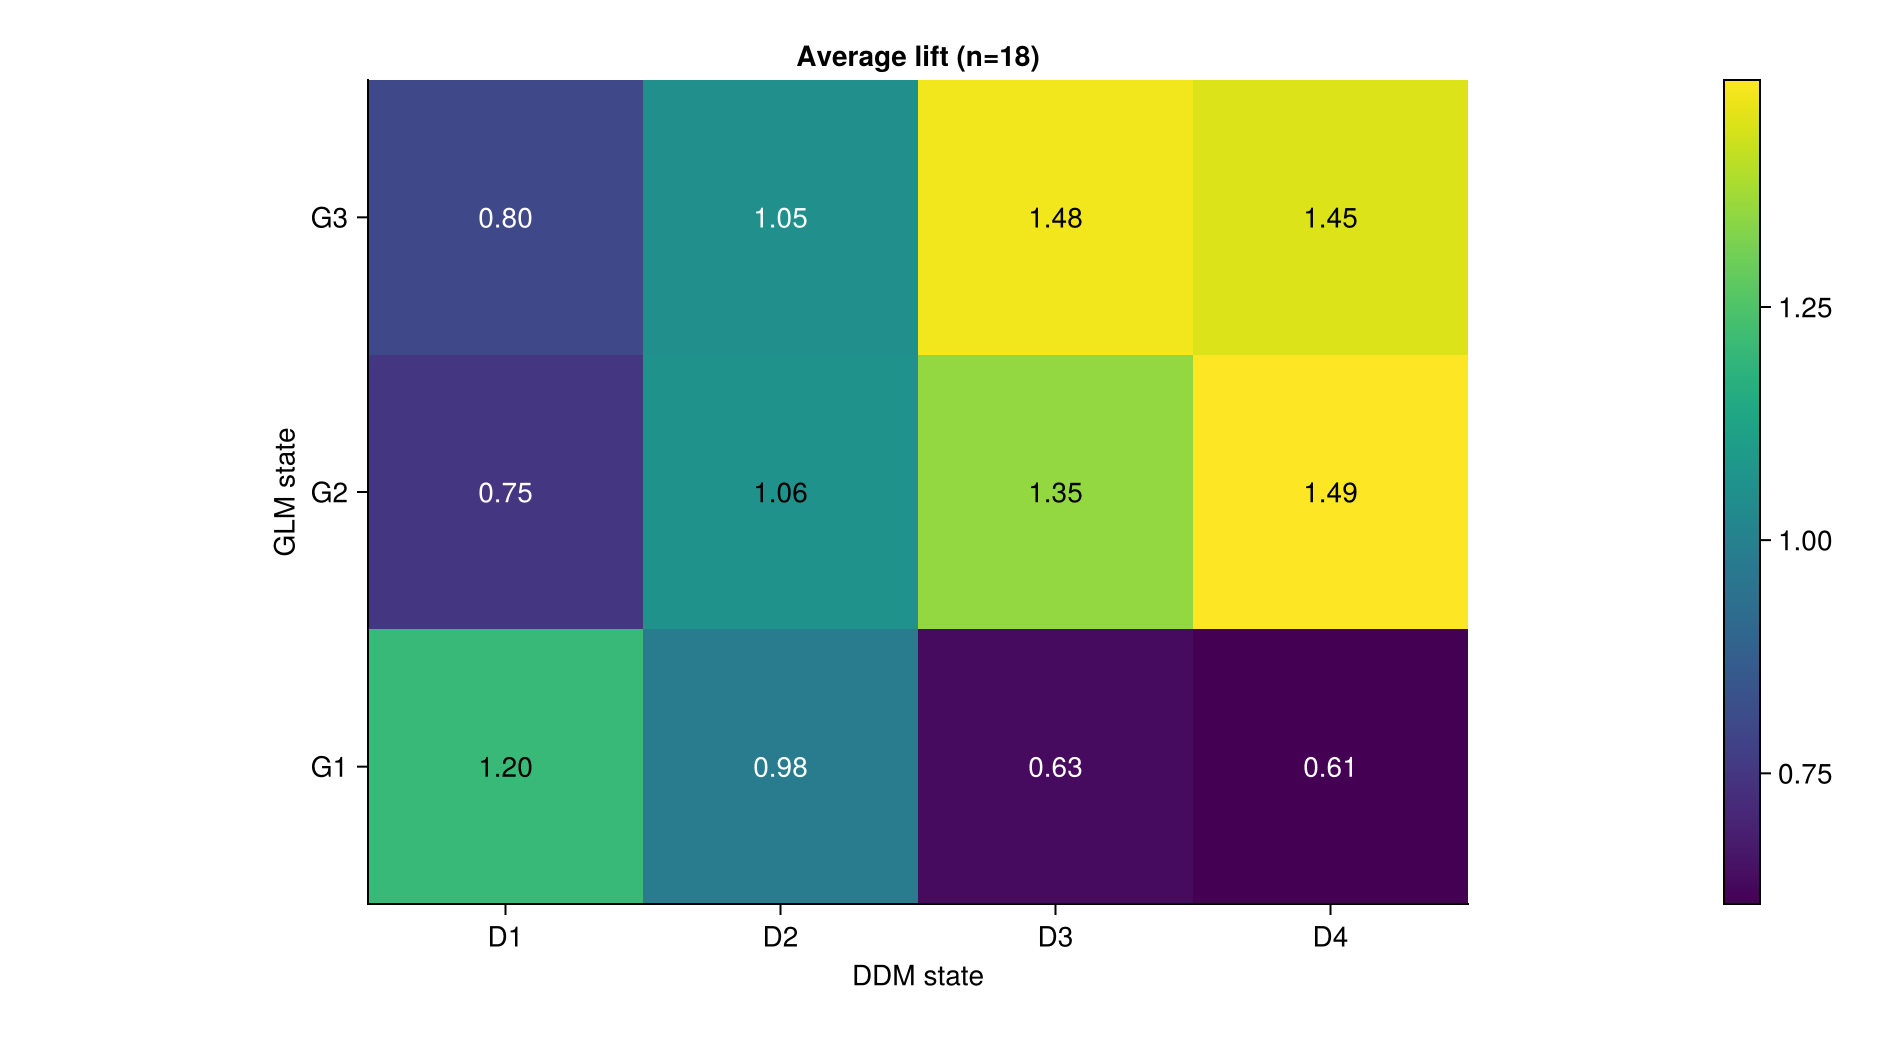

CairoMakie.Screen{EPS}


In [119]:
function pretty_lift_heatmap(avg_lift; title="Average lift", fontsize=14, figsize=(950, 520))
    K1, K2 = size(avg_lift)  # K1=GLM rows, K2=DDM cols

    fig = Figure(size=figsize, figure_padding=(25, 35, 25, 20))  # L,R,B,T
    ax = Axis(fig[1,1];
        title=title,
        xlabel="DDM state",
        ylabel="GLM state",
        aspect=DataAspect(),
        xgridvisible=false,
        ygridvisible=false,
        topspinevisible=false,
        rightspinevisible=false,
    )

    # Plot transposed so x=DDM (1..K2), y=GLM (1..K1)
    hm = CairoMakie.heatmap!(ax, avg_lift')

    # Ticks
    ax.xticks = (1:K2, ["D$(j)" for j in 1:K2])
    ax.yticks = (1:K1, ["G$(i)" for i in 1:K1])

    # Keep cells fully visible / centered
    CairoMakie.xlims!(ax, 0.5, K2 + 0.5)
    CairoMakie.ylims!(ax, 0.5, K1 + 0.5)

    # Colorbar
    Colorbar(fig[1,2], hm, width=18)

    # Contrast-aware annotation colors
    lo, hi = extrema(avg_lift)
    mid = (lo + hi) / 2

    for j in 1:K2          # x (DDM)
        for i in 1:K1      # y (GLM)
            v = avg_lift[i, j]  # original indexing: (GLM, DDM)
            tc = (v < mid) ? :white : :black
            text!(ax, j, i;
                text=@sprintf("%.2f", v),
                align=(:center, :center),
                color=tc,
                fontsize=fontsize
            )
        end
    end

    return fig
end

fig = pretty_lift_heatmap(avg_lift; title="Average lift (n=$n_used)")
display(fig)

save("model_comparison_lift_heatmap.eps", fig)

In [115]:
"""
lift_to_conditional(L, p_j) -> P(j|i)

L is K1×K2 lift matrix.
p_j is length-K2 marginal probabilities for ddm states (sum to 1).
Returns K1×K2 row-stochastic matrix P(j|i).
"""
function lift_to_conditional(L::AbstractMatrix, p_j::AbstractVector)
    K1, K2 = size(L)
    length(p_j) == K2 || throw(ArgumentError("p_j must have length K2=$K2"))
    pj = reshape(p_j, 1, :)

    P = L .* pj                   # unnormalized
    Z = sum(P, dims=2)            # row sums
    P = P ./ Z
    P[.!isfinite.(P)] .= 0
    return P
end

C = confusion_matrix(p_glm, p_ddm; mode=:soft, normalize=nothing)
p_j = vec(sum(C, dims=1)) ./ sum(C)   # ddm marginal, length K2
L = lift_matrix(C)

Pj_given_i = lift_to_conditional(L, p_j)  # this is proper probabilities

Cpop = C                     # K1×K2 raw (sum across animals; not normalized)

Pji = Cpop ./ sum(Cpop, dims=2)                  # P(j|i)
Pji[.!isfinite.(Pji)] .= 0

pj = vec(sum(Cpop, dims=1)) ./ sum(Cpop)         # P(j)

Δ = Pji .- reshape(pj, 1, :)                     # Δ = P(j|i) - P(j)


3×4 Matrix{Float64}:
 -0.00505839   0.0107384   0.00554544  -0.0112254
  0.132945    -0.0506478  -0.0321381   -0.050159
 -0.116279     0.0331028   0.0226169    0.0605597